# SIG/GIS vs RBIG — Convergence Comparison
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/rbig/blob/main/docs/notebooks/15_sig_vs_rbig_convergence.ipynb)

RBIG and GIS both Gaussianize data with greedy layer stacks, but they
spend their budget very differently:

- **RBIG** (`AnnealedRBIG`): many *cheap* layers — a fixed-family rotation
  (PCA/ICA/random) followed by marginal Gaussianization of **all**
  dimensions.
- **GIS** (`GIS`): few *expensive* layers — Stiefel-optimized projection
  directions, RQ-spline Gaussianization of only $K$ slices.

This notebook fits both on the same data and compares **convergence speed
(test log-likelihood vs layer count)**, **final log-likelihood**, and
**wall-clock time**, on a 2D benchmark and a moderate-dimensional one.

> **Colab / fresh environment?** Run the cell below to install `rbig` from
> GitHub. Skip if already installed.

In [ ]:
!pip install "rbig[all] @ git+https://github.com/jejjohnson/rbig.git" -q

In [2]:
%matplotlib inline
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from rbig import GIS, AnnealedRBIG

plt.style.use("seaborn-v0_8-paper")

/home/user/rbig/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

- **Banana (2D)**: a Gaussian bent along a parabola.
- **Rotated Skew (8D)**: independent Gamma(2) sources mixed by a fixed
  random rotation — unimodal but strongly skewed in every direction, and
  enough dimensions that *where* you rotate starts to matter.

In [3]:
def make_banana(n_samples: int, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    x = rng.standard_normal((n_samples, 2))
    return np.stack([x[:, 0], x[:, 1] + 0.5 * x[:, 0] ** 2 - 1.0], axis=1)


def make_rotated_skew(n_samples: int, seed: int = 0, d: int = 8) -> np.ndarray:
    rng = np.random.default_rng(seed)
    sources = rng.gamma(shape=2.0, scale=1.0, size=(n_samples, d))
    rotation = stats.ortho_group.rvs(d, random_state=123)  # fixed mixing
    return sources @ rotation.T


datasets = {
    "Banana (2D)": (make_banana(5_000, 0), make_banana(5_000, 42)),
    "Skew (8D)": (make_rotated_skew(3_000, 1), make_rotated_skew(3_000, 43)),
}

## Fit Both Models

Identical layer budgets; each model uses its own default early stopping
(validation log-likelihood for GIS, total-correlation change for RBIG).

In [4]:
fits = {}
for name, (X_tr, _) in datasets.items():
    t0 = time.perf_counter()
    gis = GIS(n_layers=60, random_state=0).fit(X_tr)
    t_gis = time.perf_counter() - t0

    t0 = time.perf_counter()
    rbig = AnnealedRBIG(n_layers=60, random_state=0).fit(X_tr)
    t_rbig = time.perf_counter() - t0

    fits[name] = {"GIS": (gis, t_gis), "RBIG": (rbig, t_rbig)}
    print(
        f"{name:12s}  GIS: {gis.n_layers_:3d} layers in {t_gis:5.1f}s | "
        f"RBIG: {len(rbig.layers_):3d} layers in {t_rbig:5.1f}s"
    )

Banana (2D)   GIS:  20 layers in   7.9s | RBIG:  22 layers in  20.9s


Skew (8D)     GIS:   8 layers in  16.0s | RBIG:  60 layers in  83.7s


## Test Log-Likelihood vs Layer Count

Both models are normalizing flows, so we can replay held-out data through
the fitted layers one at a time, accumulating the log-determinant, and
evaluate the mean log-likelihood after every layer — a directly comparable
convergence trajectory.

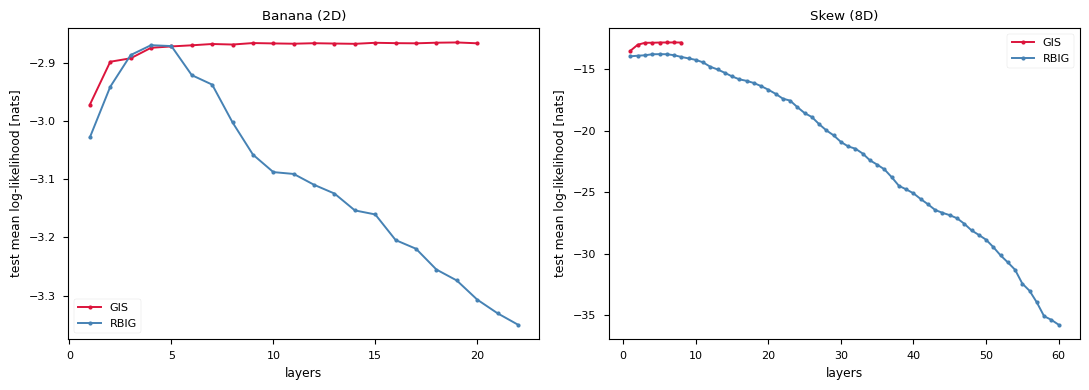

In [5]:
def ll_curve_gis(model: GIS, X: np.ndarray) -> np.ndarray:
    """Mean test log-likelihood after each GIS layer."""
    log_det = np.zeros(X.shape[0])
    if model.whitener_ is not None:
        log_det += model.whitener_.log_det_jacobian(X)
        Xt = model.whitener_.transform(X)
    else:
        Xt = X.copy()
    lls = []
    for layer in model.layers_:
        Xt, ld = layer.transform(Xt)
        log_det += ld
        lls.append(np.mean(np.sum(stats.norm.logpdf(Xt), axis=1) + log_det))
    return np.asarray(lls)


def ll_curve_rbig(model: AnnealedRBIG, X: np.ndarray) -> np.ndarray:
    """Mean test log-likelihood after each RBIG layer."""
    Xt = X.copy()
    log_det = np.zeros(X.shape[0])
    lls = []
    for layer in model.layers_:
        log_det += layer.log_det_jacobian(Xt)
        Xt = layer.transform(Xt)
        lls.append(np.mean(np.sum(stats.norm.logpdf(Xt), axis=1) + log_det))
    return np.asarray(lls)


curves = {}
for name, (_, X_te) in datasets.items():
    gis, _ = fits[name]["GIS"]
    rbig, _ = fits[name]["RBIG"]
    curves[name] = {
        "GIS": ll_curve_gis(gis, X_te),
        "RBIG": ll_curve_rbig(rbig, X_te),
    }

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, cc) in zip(axes, curves.items()):
    for model_name, color in [("GIS", "crimson"), ("RBIG", "steelblue")]:
        ll = cc[model_name]
        ax.plot(np.arange(1, ll.size + 1), ll, "o-", ms=3, color=color, label=model_name)
    ax.set_xlabel("layers")
    ax.set_ylabel("test mean log-likelihood [nats]")
    ax.set_title(name)
    ax.legend()
plt.tight_layout()
plt.show()

GIS converges in a handful of targeted layers and *stays* at its final
level on held-out data. RBIG improves in smaller increments per layer —
PCA rotations expose structure only indirectly — and in the 8D case its
test log-likelihood degrades as layers accumulate: each histogram-CDF
marginal step saturates for test points near the training-support
boundary, and those errors compound over many layers (see the
[boundary behavior notebook](18_sig_boundary_behavior.ipynb)). GIS's
RQ splines extrapolate linearly and avoid this failure mode.

## Native Stopping Metrics

Each model also records its own stopping signal during fit: validation
log-likelihood for GIS (`stopping_criterion_.history_`), residual total
correlation for RBIG (`tc_per_layer_`).

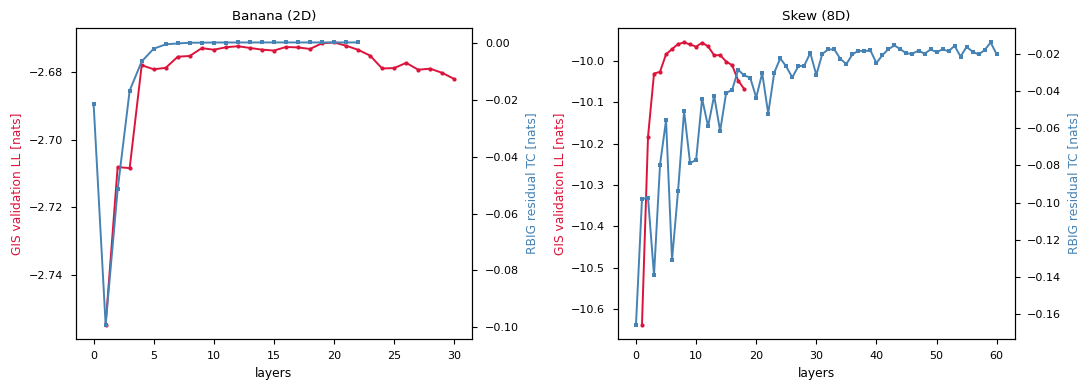

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, datasets):
    gis, _ = fits[name]["GIS"]
    rbig, _ = fits[name]["RBIG"]
    hist = np.asarray(gis.stopping_criterion_.history_)
    ax.plot(np.arange(1, hist.size + 1), hist, "o-", ms=3, color="crimson", label="GIS val. LL")
    ax2 = ax.twinx()
    tc = np.asarray(rbig.tc_per_layer_)
    ax2.plot(np.arange(tc.size), tc, "s-", ms=3, color="steelblue", label="RBIG residual TC")
    ax.set_xlabel("layers")
    ax.set_ylabel("GIS validation LL [nats]", color="crimson")
    ax2.set_ylabel("RBIG residual TC [nats]", color="steelblue")
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Final Scores and Wall-Clock Time

In [7]:
print(f"{'data':12s} {'model':6s} {'test LL':>9s} {'layers':>7s} {'fit time':>9s}")
summary = {}
for name, (_, X_te) in datasets.items():
    for model_name in ["GIS", "RBIG"]:
        model, t_fit = fits[name][model_name]
        ll = model.score(X_te)
        n_l = model.n_layers_ if model_name == "GIS" else len(model.layers_)
        summary[(name, model_name)] = (ll, n_l, t_fit)
        print(f"{name:12s} {model_name:6s} {ll:9.3f} {n_l:7d} {t_fit:8.1f}s")

data         model    test LL  layers  fit time
Banana (2D)  GIS       -2.867      20      7.9s


Banana (2D)  RBIG      -3.349      22     20.9s
Skew (8D)    GIS      -12.851       8     16.0s


Skew (8D)    RBIG     -35.757      60     83.7s


Representative run (timings vary across machines; log-likelihoods are
deterministic given the seeds):

| Data | Model | Test LL (nats) | Layers | Fit time |
|------|-------|----------------|--------|----------|
| Banana (2D) | GIS | −2.87 | 20 | ~8 s |
| Banana (2D) | RBIG | −3.35 | 22 | ~18 s |
| Skew (8D) | GIS | −12.85 | 8 | ~12 s |
| Skew (8D) | RBIG | −35.76 | 60 (cap) | ~68 s |

In 8D, GIS reaches a far better held-out log-likelihood with 8 layers than
RBIG manages with 60 — and RBIG hit the layer cap without converging.

## When to Prefer Which

| Situation | Prefer | Why |
|-----------|--------|-----|
| Information-theoretic measures (entropy, TC, MI) | **RBIG** | `rbig_measures` estimators are built on RBIG's TC-reduction accounting |
| Density estimation in moderate/high D | **GIS** | targeted directions converge in far fewer layers |
| Generative sampling | **SIG** | same flow, SWD stopping tracks sample quality |
| Very low D, quick baseline | **RBIG** | cheap layers, simple and battle-tested |
| Few layers desired (e.g. interpretability) | **GIS** | each layer is individually meaningful (learned direction) |

## See Also

- [Theory — RBIG vs SIG/GIS](../notes/sliced_iterative_gaussianization.md)
- [GIS Demo](14_sliced_gaussianization.ipynb)
- [Density Estimation Quality](16_gis_density_estimation.ipynb)